# 5. Advanced - leave-one-out cross validation

In Tutorial 3 and 4 we have explored the moving-dots dataset in some detail (see Tutorial 3 for details on the dataset). We first fit different models to the data, then explored the effects of conditions, and finally developed so called 'group models' that share some parameters between conditions while fitting other per condition. However, which of those models is the best model? One way (but not the only) to answer this question is to use leave-one-subject-out cross validation (LOOCV), which shows which model generalizes best across subjects (see [Anderson et al., 2016](https://psycnet.apa.org/record/2016-21447-001) and [Borst & Anderson, 2024](http://jelmerborst.nl/pubs/ACTR_HsMM_MVPA_BorstAnderson_preprint.pdf)). This methods iteratively fits an HMP model to _n-1_ subjects, and then calculates the likelihood of the _nth_ subject (using the fit-transform methodology introduced in Tutorial 3). Thus, fitting and likelihood estimation are independent in this case. In this tutorial we will demonstrate how this works, starting from the eliminative method and working towards complex sequences of models.

All demos will be again on the moving-dots dataset with 5 participants. To speed up running the code you could change it to 2 participants, or if you want to have the real experience and the real likelihood values, increase it to 25, but be prepared to wait.

We start by loading the data the same way we did in the previous tutorials:

In [1]:
import os
import hmp
import numpy as np
import copy

import matplotlib.pyplot as plt
import requests


# Declaring path where the EEG data will be stored
epoch_data_path = os.path.join('sample_data', 'eeg')
os.makedirs(epoch_data_path, exist_ok=True)

# URLs of the first 5 participants in the SAT experiment, navigate the osf folder and adapt those if you want to do this tutorial on other data (e.g. P3, N2pc). You can also change 5 to 25 to do the analysis on the full dataset.
base = "https://files.osf.io/v1/resources/29tgr/providers/github/results/replication/SAT_data/"
file_urls = [base + f"processed_500Hz_{(x+1):04d}_epo.fif" for x in range(5)]

# Download and save each file if not already in folder
for i, url in enumerate(file_urls, start=1):
    file_path = os.path.join(epoch_data_path, f'S{i}_epo.fif')
    if not os.path.exists(file_path):
        response = requests.get(url)
        with open(file_path, 'wb') as f:
            f.write(response.content)

# Recovering individual files and participant names
subj_files = [os.path.join(epoch_data_path, f) for f in os.listdir(epoch_data_path) if f.endswith('.fif')]  # Create a list of files with full paths

epoch_data, info = hmp.io.read_mne_epochs(subj_files,
                            montage='biosemi64',
                            verbose=False)#Turning verbose off for the documentation but it is recommended to leave it on as some output from MNE might be useful

## The following is just for this tutorial dataset and probably not needed for yours
# The duration (i.e. reaction time) data is in milliseconds and we want it in seconds
epoch_data['RT'] /= 1000
# This dataset is in microV, we want the unit in V
epoch_data *= 1e-6

base_data_noPCA = hmp.basedata.from_io(epoch_data)
base_data_noPCA.crop_reject_epochs(duration_id='RT', min_duration=.2, max_duration=2, reject_amplitude=1e-4, center=True)

base_data = copy.deepcopy(base_data_noPCA)
base_data.project(hmp.projectors.PCA(n_comp=10))
base_data.apply_variance_ops()

pattern_data = hmp.patterndata.PatternData.from_basedata(base_data)

#from now on we set cpus to the max, as many of these cells take considerable time
import os
cpus = os.cpu_count()
print('nr of cpus: ', cpus)

Found 900 trials with positively defined durations and 20 trials without durations (0 or nan)

Rejection summary: 
 0 trials rejected based on threshold of 0.0001 
 1 trials rejected  based on duration limit of (0.2, 2) 
 0 with duration but without data (nan at time 0)
nr of cpus:  18


However, note that we created a `base_data` and an `base_data_noPCA` dataset, more on that later.

## Log-likelihood

Let's first just fit a three event model:

Estimating 3 events model


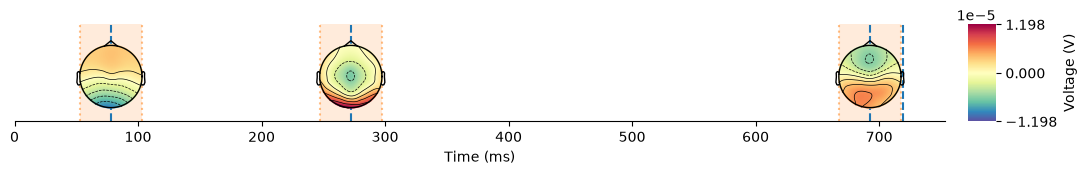

In [15]:
model_3ev = hmp.models.EventModel(n_events=3)
lkh_3ev, estimates_3ev = model_3ev.fit_transform(data=pattern_data, cpus=1)
hmp.visu.plot_model(epoch_data, estimates_3ev, info, as_time=True)

As we have seen in Tutorial 1, the log-likelihood calculated across all samples is maximized by the EM method:

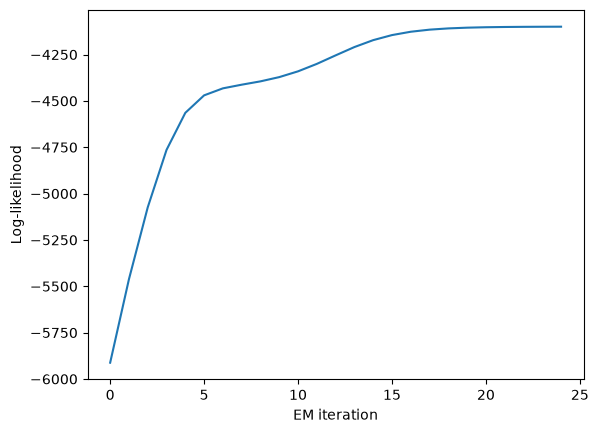

In [16]:
plt.plot(model_3ev.traces)
plt.ylabel('Log-likelihood')
plt.xlabel('EM iteration')
plt.show()

This suggests that we could simply compare the log-likelihood (lkh) of different models, and take the model with the highest likelikhood. Unfortunately, if we make the model more complex, we also give it more free parameters to fit the data, potentially leading to overfitting: that is, getting a higher likelihood without it being a 'better' model.

Traditionally, one would expect the likelihood to increase with more free parameters, but in the case of HMP that is not always what we find. As shown in Tutorial 2, the likelihood evolves in a complex manner with the number of events. On the one hand, adding events tends to increase the likelihood – as the data can be fitted more precisely – but on the other hand if events start to compete for samples, the likelihood can in fact decrease. 

We can also demonstrate that on real data by fitting an eliminative model and showing the likelihood:

Estimating all solutions for maximal number of events (6)
Estimating all solutions for 5 events


  0%|          | 0/6 [00:00<?, ?it/s]

Estimating all solutions for 4 events


  0%|          | 0/5 [00:00<?, ?it/s]

Estimating all solutions for 3 events


...

Estimating all solutions for 2 events


  0%|          | 0/3 [00:00<?, ?it/s]

Estimating all solutions for 1 events


  0%|          | 0/2 [00:00<?, ?it/s]

/Users/Jelmer/Work/hmp26/hmp/hmp/models/eliminative.py:182: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'event' ('event',) The recommendation is to set join explicitly for this case.
  xr_eventprobs = xr.concat(event_probs, dim=pd.Index(list(self.submodels), name="n_events"))


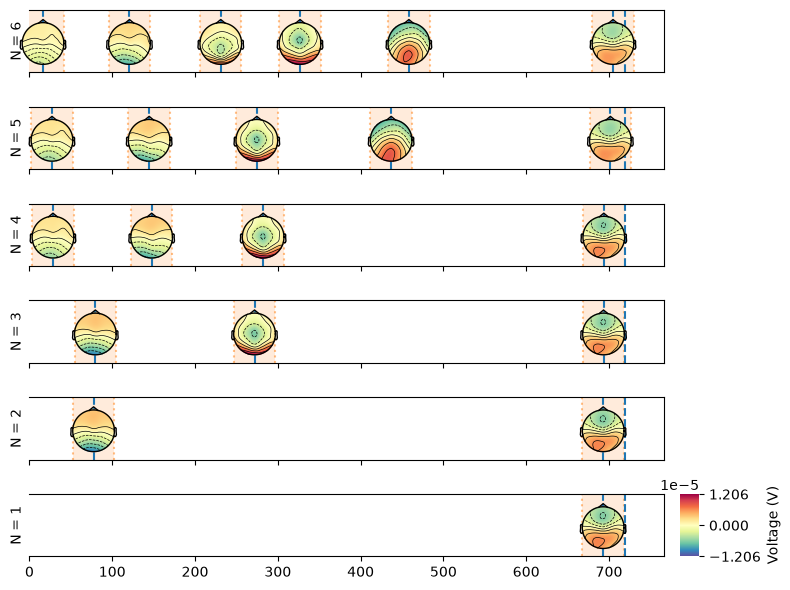

In [17]:
#eliminative model
model_elim = hmp.models.EliminativeMethod()
lkh_elim, estimates_elim = model_elim.fit_transform(data=pattern_data, cpus=cpus)
hmp.visu.plot_model(epoch_data, estimates_elim, info, as_time=True)

Text(0, 0.5, 'Log-likelihood')

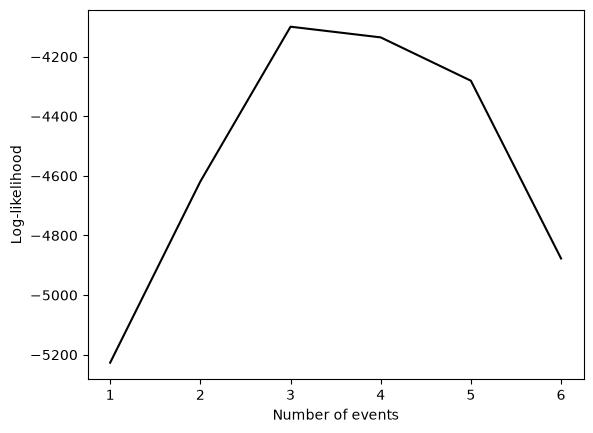

In [18]:
#plotting likelihoods
n_events_backward = [model_elim.submodels[i].n_events for i in model_elim.submodels]
plt.plot(n_events_backward, lkh_elim, 'k')
plt.xlabel('Number of events')
plt.ylabel('Log-likelihood')

The log-likelihood increases strongly to 3 events, and then starts decreasing. Thus, it seems that the 3-event model is the best model (also note that the 4-event model seems to duplicate the first event), but it might be that we are overfitting the data, which is why apply LOOCV.

## LOOCV: the basics

First, we apply LOOCV to the 3 event model, to see what the effect is on the overall log-likelihood. To do so, we build a model (with or without fitting it) and use that to build an LOOCV object and call its `fit` method.

In [19]:
model_3ev = hmp.models.EventModel(n_events=3)
loocv_3ev = hmp.loocv.LOOCV(model_3ev, quick=False, pca_cv=False)
lkh_loocv, modelfits_loocv = loocv_3ev.fit(base_data, cpus_cv=cpus, cpus_model=cpus)

Fitting models for n-1 subjects for all folds.
	Estimating model for all subjects except S1
	Estimating model for all subjects except S2
	Estimating model for all subjects except S3
	Estimating model for all subjects except S4
	Estimating model for all subjects except S5

Calculating likelihoods.
	Calculating likelihood for subject S4
	Calculating likelihood for subject S2
	Calculating likelihood for subject S5
	Calculating likelihood for subject S3
	Calculating likelihood for subject S1


As you can see, this method first estimates a model for all different _n-1_ subject models, and then calculates the corresponding likelihoods of the left-out subjects. The order is random due to parallelization of the code.

We can calculate the average model and plot it:

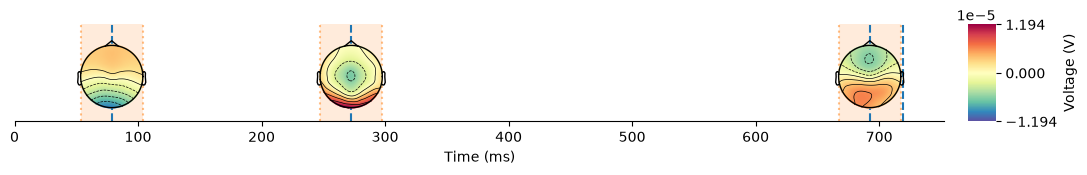

In [20]:
average_estimate, average_eventprobs = hmp.loocv.get_average_fit_eventprobs(modelfits_loocv, pattern_data)
hmp.visu.plot_model(epoch_data, average_eventprobs, info, as_time=True)

This gives us a model that is highly similar to what we've seen above. One thing to note is that the `get_average_fit_eventprobs` function simply averages the time parameters and channel parameters of the _n_ models, but does not refit anything. So this might give surprising results if the underlying models are not all the same. To make sure they are, you could, for example, inspect all separate models by plotting there time parameters:

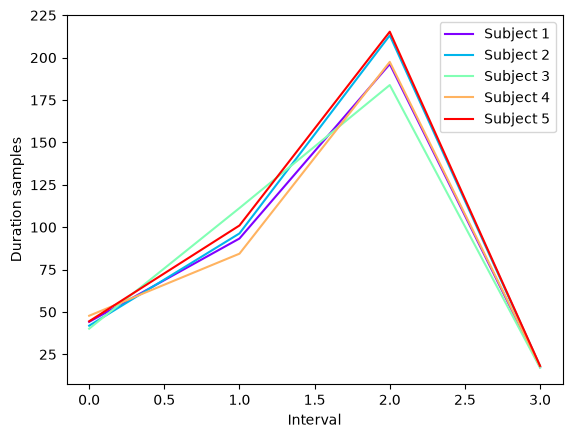

In [21]:
colors = plt.cm.rainbow(np.linspace(0, 1, 5))

for subject, estimate in enumerate(modelfits_loocv.data[0]):
    plt.plot(range(4), np.prod(estimate.time_pars[0],axis=1),label=f"Subject {subject+1}",
            color=colors[subject])

plt.ylabel('Duration samples')
plt.xlabel('Interval')
plt.legend()
plt.show()

Here, the time parameters seems highly similar, so we can trust the average model that we've shown above.

Next, let's take a look at the likelihoods:

In [22]:
lkh_loocv

<xarray.DataArray 'loo_likelihood' (n_event: 1, subject: 5)> Size: 40B
array([[ -872.26696777, -1117.03479004,  -971.33190918,  -955.85229492,
         -851.28594971]])
Coordinates:
  * n_event  (n_event) int64 8B 3
  * subject  (subject) object 40B 'S1' 'S2' 'S3' 'S4' 'S5'
Attributes:
    model_class:  <class 'hmp.models.event.EventModel'>
    model:        <hmp.models.event.EventModel object at 0x154a7cb00>
    dimension:    subject
    n_events:     [3 3 3 3 3]
    quick:        False

Here, we see the likelihood per left-out subject, with as attributes the model class and the input model. Also, the number of events per model, which in this case is necessarily 3 (but see below at the cumulative method).

Given that the likelihood can be summed across samples we can now compare this to the overall likelihood that we calculated earlier:

In [23]:
print('LOOCV lkh: ', np.round(np.sum(lkh_loocv.values)))
print('Single model lkh: ', np.round(lkh_3ev[0]))

LOOCV lkh:  -4768.0
Single model lkh:  -4100.0


As you might have expected, the single model lkh is higher, as in that case the estimate can profit from all samples. This illustrates the necessity of a method like LOOCV to prevent overfitting.

Let's now apply this method to the eliminative method, so we can identify the model with the most probably number of events. The only thing that we need to change is the model that we use as input for the LOOCV object. Note that it will take a while to run the code below.

In [24]:
model_elim = hmp.models.EliminativeMethod()
loocv_elim = hmp.loocv.LOOCV(model_elim, quick=False, pca_cv=False)
lkh_loocv_elim, modelfits_loocv_elim = loocv_elim.fit(pattern_data, cpus_cv=cpus, cpus_model=1)

Fitting models for n-1 subjects for all folds.
	Estimating model for all subjects except S1
	Estimating model for all subjects except S3
	Estimating model for all subjects except S2
	Estimating model for all subjects except S4
	Estimating model for all subjects except S5

Calculating likelihoods.
	Calculating likelihood for subject S5
	Calculating likelihood for subject S2
	Calculating likelihood for subject S3
	Calculating likelihood for subject S4
	Calculating likelihood for subject S1
Calculating likelihoods.
	Calculating likelihood for subject S3
	Calculating likelihood for subject S1
	Calculating likelihood for subject S2
	Calculating likelihood for subject S5
	Calculating likelihood for subject S4
Calculating likelihoods.
	Calculating likelihood for subject S1
	Calculating likelihood for subject S3
	Calculating likelihood for subject S2
	Calculating likelihood for subject S4
	Calculating likelihood for subject S5
Calculating likelihoods.
	Calculating likelihood for subject S1
	Ca

For the LOOCV fit method, we have two `cpu` arguments, one for the cross validation itself and one for the underlying models. In general, we suggest to set `cpus_cv` as high as your cpus and RAM allow.

As before, we can plot the average models (we will just assume these are all the same underlying models in this case):

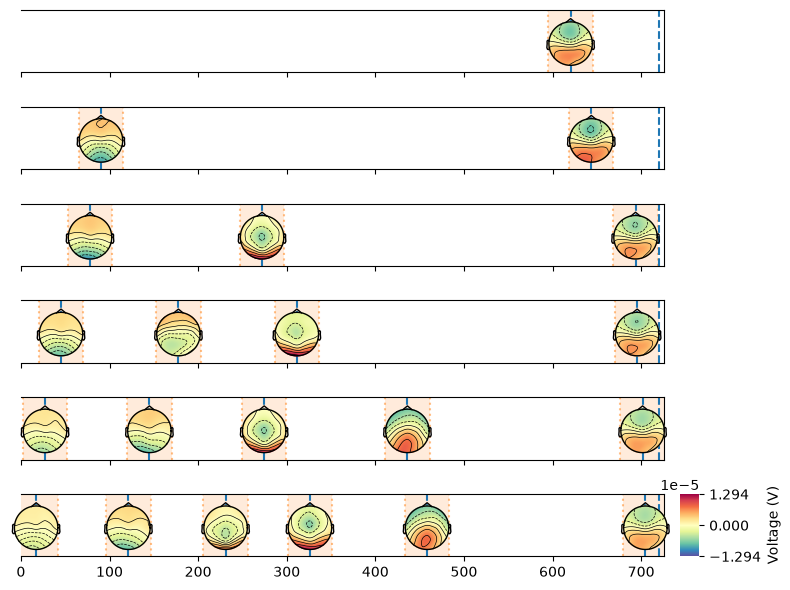

In [25]:
average_estimate, average_eventprobs = hmp.loocv.get_average_fit_eventprobs(modelfits_loocv_elim, pattern_data)
hmp.visu.plot_model(epoch_data, average_eventprobs, info, as_time=True)

But now, we can also plot the likelihood development:

[(np.float64(0.5), np.float64(1.0)),
 (np.float64(2.5), np.float64(0.0625)),
 (np.float64(-2.5), np.float64(0.0625)),
 (np.float64(-2.5), np.float64(0.0625)),
 (np.float64(-2.5), np.float64(0.0625))]

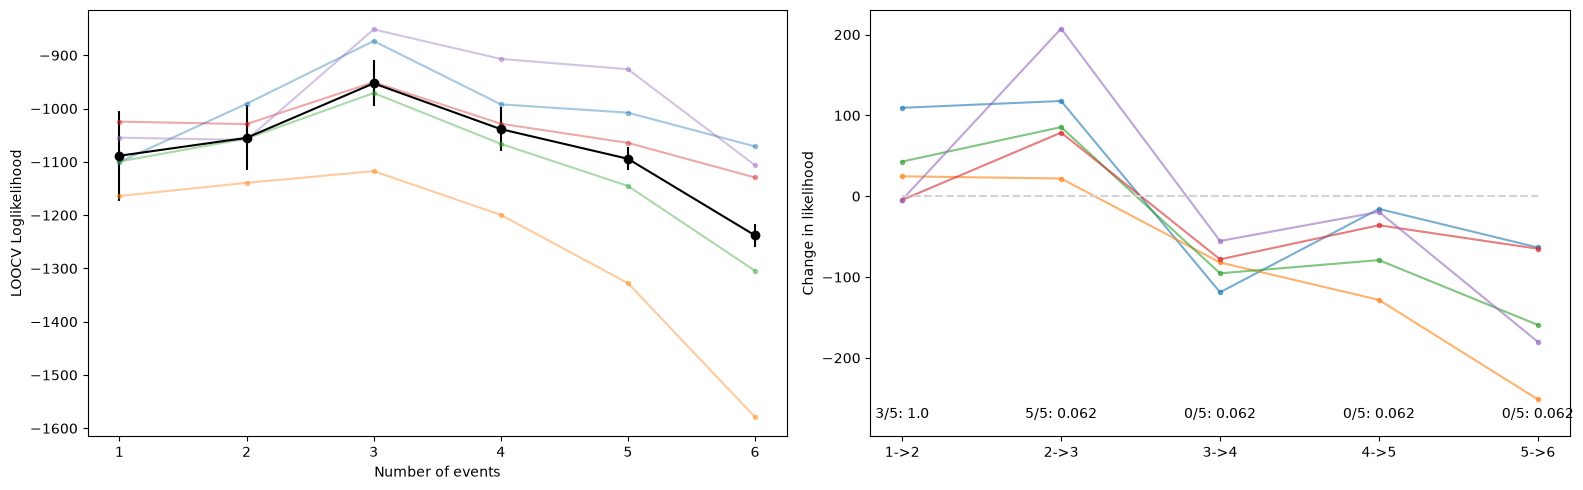

In [26]:
hmp.visu.plot_loocv(lkh_loocv_elim,pvals=True, test="sign",mean=True)


The left graph shows the likelihood development for different numbers of events. The black line indicates the average, the colored lines the individual subjects. The right graph shows how the likelihood develops when adding more events: that is, what happens when we move from 1 -> 2 events, from 2 -> 3, etc. We can see that the change is positive for all subjects when we move to 3 events, but that from then on the likelihood decreases – matching the non-LOOCV estimate above. The graph also shows for how many subjects this improves (5/5 in the case 2->3 events) and the p-value of a sign test (can be changed to a t-test).

As before, let's compare the likelihood values to the non-LOOCV model:

In [27]:
print('LOOCV lkh: ', np.round(np.sum(lkh_loocv_elim.values, axis=1)))
print('Single model lkh: ', np.round(np.transpose(np.flip(lkh_elim))))


LOOCV lkh:  [-5443. -5275. -4763. -5193. -5471. -6190.]
Single model lkh:  [[-5227. -4619. -4099. -4135. -4281. -4877.]]


Also here, the LOOCV likelihood is clearly lower overall.

## LOOCV: PCA & quick estimation

So far, we have ignored two of the arguments for the LOOCV initalization: `quick` and `pca_cv`. We have used `base_data` as the input data, and simply fit and estimated the likelihood on `base_data`. However, this means that the datasets were not fully independent, as the PCA was performed across all data, potentially leaking information between subjects. 

To avoid this issue, we can use `base_data_noPCA` as input, and set `pca_cv` to true. In this case, PCA will be applied to the _n-1_ subejcts, the model will be estimated, the same PCA weights will be applied to the _nth_ subject, and the fit calculated. This way, model estimation and likelihood calculation are fully independent. It does increase computation time a little.

In [28]:
model_3ev = hmp.models.EventModel(n_events=3)
loocv_3ev_PCAcv = hmp.loocv.LOOCV(model_3ev, pca_cv=True, pca_kwargs={'n_comp': 10})
lkh_loocv_PCAcv, modelfits_loocv_PCAcv = loocv_3ev_PCAcv.fit(base_data_noPCA, cpus_cv=cpus, cpus_model=1)

Fitting models for n-1 subjects for all folds.
	Estimating model for all subjects except S1
	Estimating model for all subjects except S2
	Estimating model for all subjects except S3
	Estimating model for all subjects except S4
	Estimating model for all subjects except S5

Calculating likelihoods.
	Calculating likelihood for subject S1
	Calculating likelihood for subject S2
	Calculating likelihood for subject S3
	Calculating likelihood for subject S4
	Calculating likelihood for subject S5
Using weights at initialization for custom projection on the data
Using weights at initialization for custom projection on the data
Using weights at initialization for custom projection on the data
Using weights at initialization for custom projection on the data
Using weights at initialization for custom projection on the data


Let's take a look at the resulting likelihoods:

In [29]:
print('LOOCV lkh, PCA cv: ', np.round(np.sum(lkh_loocv_PCAcv.values)))
print('LOOCV lkh, no PCA: ', np.round(np.sum(lkh_loocv.values)))
print('Single model lkh: ', np.round(lkh_3ev[0]))

LOOCV lkh, PCA cv:  -4535.0
LOOCV lkh, no PCA:  -4768.0
Single model lkh:  -4100.0


The PCA crossvalidation likelihood is a bit higher then the no-PCA version, but still lower than the single model. When running the eliminative model with PCA cross validation, the values are also similar and the conclusion stands (not shown because of computational time).

The other argument that we ignored so far is the `quick` argument. Setting this to true basically moves us in the other direction: we now use an overall fit to inform all _n_ models. Obviously this makes all models somewhat dependent - invalidating the LOOCV results. However, generally we find that the results are highly similar, and this method is much faster to run. So we advice to use this for quick exploration, but always run a correct LOOCV at the end.

Let's apply it to the eliminative method. When using `quick` a fitted model is required.

In [31]:
model_elim_fit = hmp.models.EliminativeMethod()
model_elim_fit.fit(data=pattern_data, cpus=cpus)
loocv_elim_quick = hmp.loocv.LOOCV(model_elim_fit, quick=True)
lkh_loocv_elim_quick, modelfits_loocv_elim_quick = loocv_elim_quick.fit(pattern_data, cpus_cv=cpus, cpus_model=1)

Estimating all solutions for maximal number of events (6)
Estimating all solutions for 5 events


  0%|          | 0/6 [00:00<?, ?it/s]

Estimating all solutions for 4 events


  0%|          | 0/5 [00:00<?, ?it/s]

Estimating all solutions for 3 events


...

Estimating all solutions for 2 events


  0%|          | 0/3 [00:00<?, ?it/s]

Estimating all solutions for 1 events


  0%|          | 0/2 [00:00<?, ?it/s]


IMPORTANT: 'quick' set to true, requesting a fast LOOCV procedure.

Note that the quick procedure is typically incorrect in the sense
that an initial model fit is used to inform both the fit of the
left-out participant and the other participants.

This means that the fits are not independent, unless the initial
model fit is based on the literature or another task. However, it
typically provides a good initial model fit of the correct LOOCV
procedure and is relatively quick.
Fitting models for n-1 subjects for all folds.
	Estimating model for all subjects except S1
	Estimating model for all subjects except S2
	Estimating model for all subjects except S3
	Estimating model for all subjects except S4
	Estimating model for all subjects except S5

Calculating likelihoods.
	Calculating likelihood for subject S2
	Calculating likelihood for subject S1
	Calculating likelihood for subject S3
	Calculating likelihood for subject S4
	Calculating likelihood for subject S5
Calculating likelihoods.
	C

On my machine, this takes 1m 15s instead of 2m 13s above. Obviously this advantage increases with more subjects.

The output is similar (but higher) as before, and is closer to the single model likelihood:

In [32]:
print('LOOCV quick: ', np.round(np.sum(lkh_loocv_elim_quick.values, axis=1)))
print('LOOCV lkh: ', np.round(np.sum(lkh_loocv_elim.values, axis=1)))
print('Single model lkh: ', np.round(np.transpose(np.flip(lkh_elim))))

LOOCV quick:  [-5333. -4948. -4740. -5035. -5438. -6149.]
LOOCV lkh:  [-5443. -5275. -4763. -5193. -5471. -6190.]
Single model lkh:  [[-5227. -4619. -4099. -4135. -4281. -4877.]]


## Cumulative models

Up to this point, we have used models with the same numbers of events. We can also apply LOOCV to the cumulative method. However, especially with fewer subjects this might lead to quite different models.

In [33]:
model_cumulative = hmp.models.CumulativeMethod()
loocv_cumu = hmp.loocv.LOOCV(model_cumulative, quick=False) #quick not possible for cumulative
lkh_loocv_cumu, modelfits_loocv_cumu = loocv_cumu.fit(pattern_data, cpus_cv=cpus, cpus_model=1)

lkh_loocv_cumu

Fitting models for n-1 subjects for all folds.
	Estimating model for all subjects except S2
	Estimating model for all subjects except S1
	Estimating model for all subjects except S3
	Estimating model for all subjects except S4
	Estimating model for all subjects except S5


100%|██████████| 28/28 [04:11<00:00, 20.34s/it]


Calculating likelihoods.


29it [04:11,  8.68s/it]                        


	Calculating likelihood for subject S5
	Calculating likelihood for subject S1
	Calculating likelihood for subject S3
	Calculating likelihood for subject S4
	Calculating likelihood for subject S2


<xarray.DataArray 'loo_likelihood' (n_event: 1, subject: 5)> Size: 40B
array([[ -992.13037109, -1329.77539062,  -971.35131836, -1065.97595215,
         -858.06359863]])
Coordinates:
    n_event  <U8 32B 'variable'
  * subject  (subject) object 40B 'S1' 'S2' 'S3' 'S4' 'S5'
Attributes:
    model_class:  <class 'hmp.models.cumulative.CumulativeMethod'>
    model:        <hmp.models.cumulative.CumulativeMethod object at 0x334bd6510>
    dimension:    subject
    n_events:     [4 5 3 5 4]
    quick:        False

Indeed, in the summary we can see that the number of events varied between 3 and 5. If we request an average, it will take this into account and make an average per number of events (but it doesn't check if the models themselves are comparable in any way).

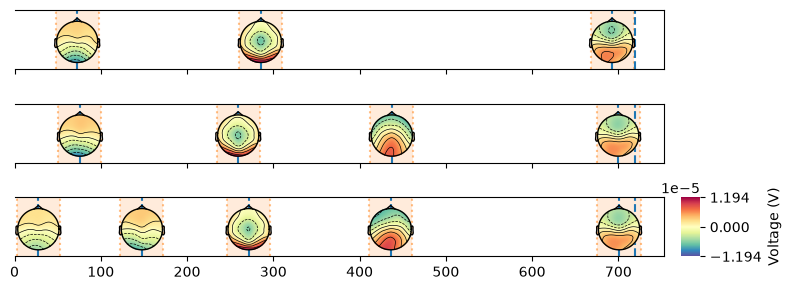

In [34]:
average_estimate, average_eventprobs = hmp.loocv.get_average_fit_eventprobs(modelfits_loocv_cumu, pattern_data)
hmp.visu.plot_model(epoch_data, average_eventprobs, info, as_time=True)

## Advanced comparisons

Above, we used LOOCV to identify the 'correct' number of events. However, we can also use it to make more complex comparisons. For example, we could fit a grouped model with four conditions, as we've done in Tutorial 4, and compare the results to the overall 3-event model. 

First, we apply LOOCV to the grouped model:

In [35]:
grouping_dict = {'cue': ['SP', 'AC'], 'resp': ['resp_right', 'resp_left']}  # Define conditions
channel_map = np.array([[0, 0, -1, 0],    # third event missing for speed, left/right resp division
                        [0, 0, -1, 1],
                        [0, 0, 0, 0],
                        [0, 0, 0, 1]])
time_map = np.array([[0, 0, -1, 0, 0],    # one stage missing, one stage could be different
                     [0, 0, -1, 0, 0],
                     [0, 0, 0, 1, 0],
                     [0, 0, 0, 1, 0]])

model_group = hmp.models.EventModel(n_events=4, channel_map=channel_map, time_map=time_map, grouping_dict=grouping_dict)
loocv_grouped = hmp.loocv.LOOCV(model_group, quick=False, pca_cv=True, pca_kwargs={'n_comp': 10})
lkh_loocv_grouped, modelfits_loocv_grouped = loocv_grouped.fit(base_data_noPCA, cpus_cv=cpus, cpus_model=1)

Fitting models for n-1 subjects for all folds.
	Estimating model for all subjects except S1
	Estimating model for all subjects except S2
	Estimating model for all subjects except S3
	Estimating model for all subjects except S4
	Estimating model for all subjects except S5

Calculating likelihoods.
	Calculating likelihood for subject S1
	Calculating likelihood for subject S2
	Calculating likelihood for subject S3
	Calculating likelihood for subject S4
Using weights at initialization for custom projection on the data
	Calculating likelihood for subject S5
Using weights at initialization for custom projection on the data
Using weights at initialization for custom projection on the data
Using weights at initialization for custom projection on the data
Using weights at initialization for custom projection on the data


We can now compare these likelihoods to the 3-event model (with PCA cross validation) that we developed above:

In [36]:
print('LOOCV lkh grouped, PCA cv: ', lkh_loocv_grouped.values)
print('LOOCV lkh 3 events, PCA cv: ', lkh_loocv_PCAcv.values)


LOOCV lkh grouped, PCA cv:  [[ -869.90765381 -1110.12890625  -936.19726562  -950.38909912
   -801.38928223]]
LOOCV lkh 3 events, PCA cv:  [[ -827.29827881 -1094.99682617  -918.27526855  -890.41333008
   -803.70471191]]


It looks like the 3-event model has a higher likelihood. Let's test that:

In [37]:
print('For how many subject is the 3-event model better?')
print(np.sum((lkh_loocv_PCAcv.values - lkh_loocv_grouped.values) > 0))

For how many subject is the 3-event model better?
4


Indeed, the simpler 3 event model, also has the higher likelihood. However, note that the models in this tutorial are based on little data (especially if we start grouping conditions), so it might be worth repeating this with all subjects.

## Functions

We will finish this tutorial with a more complex LOOCV example. Typically, we develop a sequence of models. For example, we first use the cumulative or the eliminative method to identify a basic model, and then use group modeling to deal with condition differences. If we apply LOOCV, we have to keep this whole sequence independent between subject. To that end, we can define the model development as a function, as use that function as input to LOOCV.

First, we define the function:

In [8]:
def example_complex_func(data, max_events=None):
  
    # fit backward model up to max_events
    eliminative_model = hmp.models.EliminativeMethod(max_events=max_events)
    eliminative_model.fit(data)

    # fit group model
    channel_map = np.array([[0, 0, -1, 0],
                            [0, 0, 0, 0]])
    time_map = np.array([[0, 0, -1, 0, 0], 
                         [0, 0, 0, 1, 0]])
    grouping_dict = {'cue': ['SP', 'AC']} 

    group_model = hmp.models.EventModel(n_events=4,
                                        channel_map=channel_map, 
                                        time_map=time_map,
                                        grouping_dict=grouping_dict)
    group_model.fit(data=data,
                    channel_pars = eliminative_model.submodels[4].channel_pars,
                    time_pars = eliminative_model.submodels[4].time_pars)

    return [eliminative_model, group_model]

This function first fits an eliminative model upt to `max_events`, and then uses the estimated channel and time parameters to inform a group model (the same we have just used).

Next, we use this function as input to LOOCV, instead of a model and give it its arguments through `function_kwargs`.

In [9]:
loocv_complex_func = hmp.loocv.LOOCV(example_complex_func, function_kwargs={'max_events' : 5}, pca_cv=True, pca_kwargs={'n_comp': 10})
lkh_complex_func, modelfits_complex_func = loocv_complex_func.fit(base_data_noPCA, cpus_cv=1, cpus_model=cpus)

Fitting models for n-1 subjects for all folds.
	Estimating model for all subjects except S1
Estimating all solutions for maximal number of events (5)
Estimating all solutions for 4 events
Estimating all solutions for 3 events
Estimating all solutions for 2 events
Estimating all solutions for 1 events
group "cue" analyzed, with groups: ['SP', 'AC']

Coded as follows: 
0: ['SP']
1: ['AC']

Channel map:
0:  [ 0  0 -1  0]
1:  [0 0 0 0]

Time map:
0:  [ 0  0 -1  0  0]
1:  [0 0 0 1 0]
Estimating 4 events model
	Estimating model for all subjects except S2
Estimating all solutions for maximal number of events (5)
Estimating all solutions for 4 events
Estimating all solutions for 3 events
Estimating all solutions for 2 events
Estimating all solutions for 1 events
group "cue" analyzed, with groups: ['SP', 'AC']

Coded as follows: 
0: ['SP']
1: ['AC']

Channel map:
0:  [ 0  0 -1  0]
1:  [0 0 0 0]

Time map:
0:  [ 0  0 -1  0  0]
1:  [0 0 0 1 0]
Estimating 4 events model
	Estimating model for all s

As before, we can average all models and plot them.

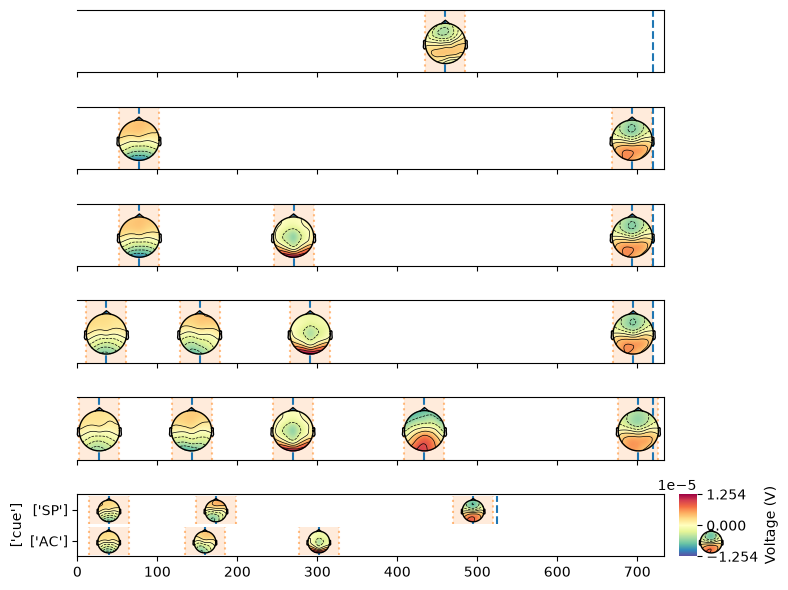

In [10]:
average_estimate, average_eventprobs = hmp.loocv.get_average_fit_eventprobs(modelfits_complex_func, pattern_data)
hmp.visu.plot_model(epoch_data, average_eventprobs, info, as_time=True)

And finally inspect the likelihood values:

In [38]:
print('LOOCV lkh complex,: ', lkh_complex_func[-1].values) #taking the final fitted model
print('LOOCV lkh grouped, PCA cv: ', lkh_loocv_grouped.values)
print('LOOCV lkh 3 events, PCA cv: ', lkh_loocv_PCAcv.values)

LOOCV lkh complex,:  [[ -940.38647461 -1275.60620117 -1040.88208008 -1038.17822266
   -919.42657471]]
LOOCV lkh grouped, PCA cv:  [[ -869.90765381 -1110.12890625  -936.19726562  -950.38909912
   -801.38928223]]
LOOCV lkh 3 events, PCA cv:  [[ -827.29827881 -1094.99682617  -918.27526855  -890.41333008
   -803.70471191]]


Less nice than before, perhaps because we only fit the eliminative model with `max_events=5`, but this would require a more detailed exploration, outside the scope of this tutorial.